# Visualização e avaliação das previsões HSI

Este notebook avalia os cubos gerados pelo CycleGAN contra o conjunto HSI real de teste.

A implementação segue a lógica usada em `CycleGANModule._run_validation()` e em `scripts/evaluate_generators.py`:

- os cubos têm 16 bandas entre aproximadamente 465 e 630 nm;
- FID compara **distribuições** de características e só é calculado para conjuntos de imagens;
- SAM e SSIM são métricas pareadas. Como o CycleGAN foi treinado com domínios não pareados, uma imagem RGB gerada não possui necessariamente um HSI real correspondente. Assim, SAM/SSIM entre arquivos sintéticos e reais alinhados por índice são apenas um **proxy não pareado**, não uma medida de reconstrução da mesma lesão;
- a assinatura espectral é a média dos pixels em cada banda. Para dados reais usamos a máscara anotada quando disponível; para sintéticos, que não possuem máscara salva, reproduzimos o fallback do repositório: Otsu sobre a imagem média e pixels mais escuros que o limiar são considerados lesão.

> Com apenas 15 imagens reais no split de teste, o FID terá alta variância. Use-o para comparação interna entre modelos avaliados com exatamente o mesmo protocolo, não como valor absoluto.

In [1]:
from pathlib import Path
import os
import sys
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.io import loadmat
from skimage.filters import threshold_otsu

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchmetrics.image import SpectralAngleMapper, StructuralSimilarityIndexMeasure
from torchmetrics.image.fid import FrechetInceptionDistance

# Funciona tanto com o kernel iniciado na raiz quanto dentro de notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / '.project-root').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
# O metadata do dataset contém caminhos relativos como data/... .
# Fixamos o diretório de trabalho na raiz para esses caminhos funcionarem
# mesmo quando o kernel do notebook inicia dentro de notebooks/.
os.chdir(PROJECT_ROOT)

from src.data_modules.hsi_dermoscopy import HSIDermoscopyDataModule
from src.data_modules.datasets.hsi_dermoscopy_dataset import HSIDermoscopyDataset
from src.metrics.inception import InceptionV3Wrapper

SEED = 114514
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project root:', PROJECT_ROOT)
print('Device:', DEVICE)

Project root: /mnt/datassd/genai/dgm-2025.2/projects/hyperskin
Device: cuda


/mnt/datassd/icasp/miniconda3/envs/genai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import glob
fastgan_files = glob.glob('generated_samples_fastgan-melanoma/*.mat')

## Configuração

As previsões foram salvas em escala física por banda durante o `predict`. Para reproduzir as métricas do treino, normalizamos real e sintético para `[0,1]` por banda; a versão `[-1,1]` é usada no FID, como em `cycle_gan.py`.

In [7]:
GENERATED_DIR = PROJECT_ROOT / 'generated_samples_cyclegan'
REAL_DATA_DIR = PROJECT_ROOT / 'data/hsi_dermoscopy_croppedv2_256_with_masks'
TEST_SPLIT_FILE = PROJECT_ROOT / 'data/splits/test.txt'

SAMPLE_INDEX = 2
REAL_REFERENCE_INDEX = 2
BATCH_SIZE = 8
NUM_WORKERS = 0  # mais robusto dentro de notebooks

GLOBAL_MIN = np.array([
    0.00028473, 0.0043945, 0.00149752, 0.00167517,
    0.00190101, 0.0028114, 0.00394378, 0.00488099,
    0.00257091, 0.00215704, 0.00797662, 0.01205248,
    0.01310135, 0.01476806, 0.01932094, 0.02020744,
], dtype=np.float32)
GLOBAL_MAX = np.array([
    0.6203158, 0.6172642, 0.46794897, 0.4325111,
    0.4996644, 0.61997396, 0.7382196, 0.86097705,
    0.88304037, 0.9397393, 1.1892519, 1.5035477,
    1.4947973, 1.4737314, 1.6318618, 1.7226081,
], dtype=np.float32)

WAVELENGTHS_NM = np.linspace(465, 630, 16)

assert GENERATED_DIR.exists(), f'Diretório não encontrado: {GENERATED_DIR}'
assert REAL_DATA_DIR.exists(), f'Diretório não encontrado: {REAL_DATA_DIR}'
assert TEST_SPLIT_FILE.exists(), f'Split não encontrado: {TEST_SPLIT_FILE}'

## Funções auxiliares

In [8]:
def extract_mat_cube(path: Path) -> np.ndarray:
    data = loadmat(path)
    arrays = [v for k, v in data.items() if not k.startswith('__') and isinstance(v, np.ndarray)]
    if not arrays:
        raise ValueError(f'Nenhum array encontrado em {path}')
    cube = arrays[-1].astype(np.float32)
    if cube.ndim != 3:
        raise ValueError(f'Esperado cubo 3D, recebido {cube.shape} em {path}')
    if cube.shape[0] == 16 and cube.shape[-1] != 16:
        cube = np.transpose(cube, (1, 2, 0))
    if cube.shape[-1] != 16:
        raise ValueError(f'Esperadas 16 bandas, recebido {cube.shape} em {path}')
    return cube


def physical_to_unit(cube: np.ndarray) -> np.ndarray:
    mins = GLOBAL_MIN.reshape(1, 1, -1)
    maxs = GLOBAL_MAX.reshape(1, 1, -1)
    return np.clip((cube - mins) / (maxs - mins + 1e-8), 0.0, 1.0).astype(np.float32)


def chw_tensor(cube_hwc_01: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(cube_hwc_01).permute(2, 0, 1).contiguous().float()


def otsu_lesion_mask(cube_hwc_01: np.ndarray) -> np.ndarray:
    mean_image = cube_hwc_01.mean(axis=-1)
    threshold = threshold_otsu(mean_image)
    return mean_image < threshold


def mean_spectra(cube_hwc: np.ndarray, lesion_mask: np.ndarray):
    lesion_mask = lesion_mask.astype(bool)
    normal_mask = ~lesion_mask
    lesion = cube_hwc[lesion_mask].mean(axis=0) if lesion_mask.any() else np.full(16, np.nan)
    normal = cube_hwc[normal_mask].mean(axis=0) if normal_mask.any() else np.full(16, np.nan)
    return lesion, normal


def load_combined_mask(mask_paths, expected_shape=(256, 256)):
    if not mask_paths:
        return None
    masks = [np.asarray(Image.open(p).convert('L')) > 0 for p in mask_paths]
    mask = np.logical_or.reduce(masks)
    if mask.shape != expected_shape:
        mask = np.asarray(
            Image.fromarray(mask.astype(np.uint8) * 255).resize(
                expected_shape[::-1], resample=Image.Resampling.NEAREST
            )
        ) > 0
    return mask

## Carregamento das previsões e do conjunto real de teste

O notebook lê o split já salvo em `data/splits/test.txt`; ele não recria nem sobrescreve os splits.

In [9]:
class GeneratedHSIDataset(Dataset):
    def __init__(self, root: Path):
        self.files = sorted(root.rglob('*.mat'))
        if not self.files:
            raise ValueError(f'Nenhum .mat encontrado em {root}')

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        physical = extract_mat_cube(self.files[index])
        unit = physical_to_unit(physical)
        return {'image': chw_tensor(unit), 'path': str(self.files[index])}


# Usamos o DataModule somente para construir a mesma transformação de teste do treino.
# prepare_data() não é chamado para evitar recriar os arquivos de split.
real_dm = HSIDermoscopyDataModule(
    task='generation',
    train_val_test_split=(0.7, 0.15, 0.15),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    data_dir=str(REAL_DATA_DIR),
    allowed_labels=['melanoma'],
    global_min=GLOBAL_MIN.tolist(),
    global_max=GLOBAL_MAX.tolist(),
    range_mode='-1_1',
    transforms={
        'test': [
            {'class_path': 'SmallestMaxSize', 'init_args': {'max_size': 256}},
            {'class_path': 'CenterCrop', 'init_args': {'height': 256, 'width': 256}},
            {'class_path': 'ToTensorV2', 'init_args': {}},
        ]
    },
)

real_base = HSIDermoscopyDataset(
    data_dir=str(REAL_DATA_DIR),
    task='generation',
    transform=real_dm.transforms_test,
    force_create_df=False,
    save_labels_df=False,
)
test_indices = np.atleast_1d(np.loadtxt(TEST_SPLIT_FILE, dtype=int))
real_test = Subset(real_base, test_indices.tolist())
fake_dataset = GeneratedHSIDataset(GENERATED_DIR)

print(f'Reais no split de teste: {len(real_test)}')
print(f'Sintéticos encontrados: {len(fake_dataset)}')
print('Classes reais no teste:', real_base.labels_df.iloc[test_indices]['label'].value_counts().to_dict())

Reais no split de teste: 15
Sintéticos encontrados: 100
Classes reais no teste: {'melanoma': 15}


## 1–2. Visualização de uma amostra e assinatura espectral

A imagem HSI não possui uma única visualização RGB canônica. Mostramos a média das 16 bandas e três bandas representativas. Em seguida, calculamos a média espectral dos pixels classificados como lesão e pele normal.

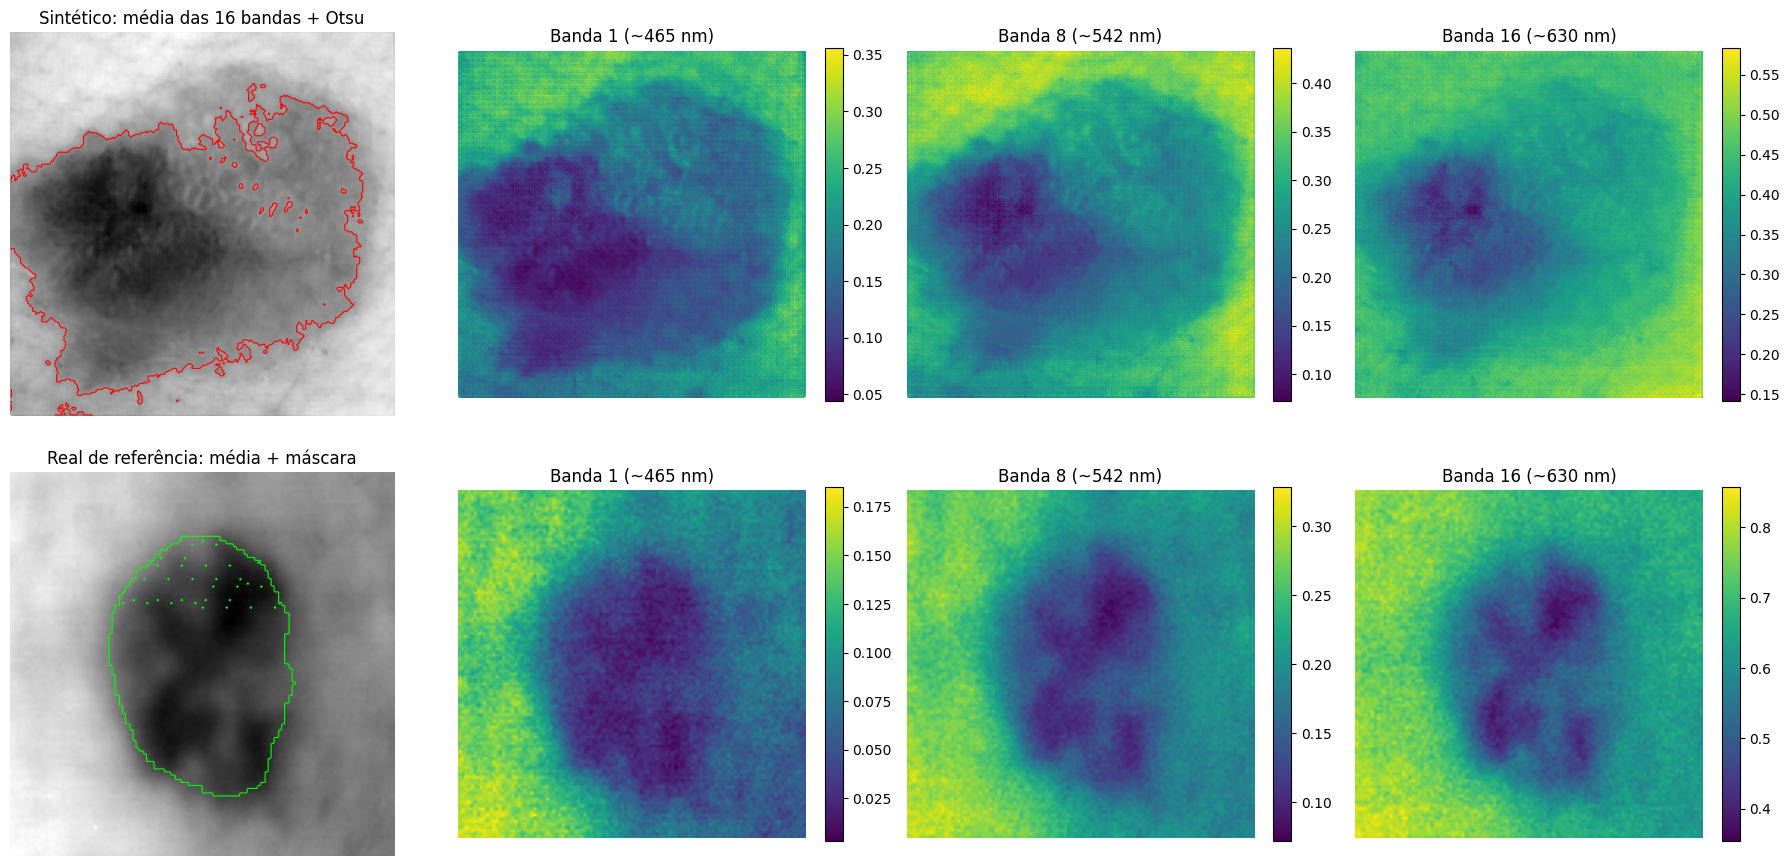

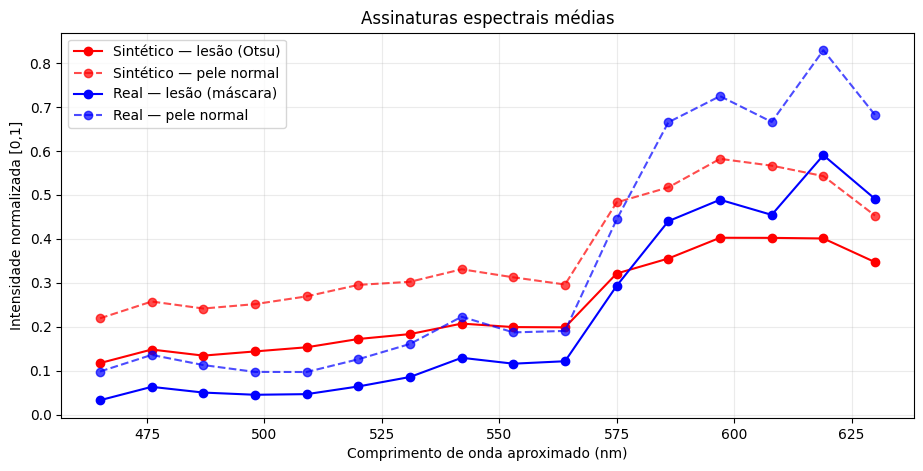

Arquivo sintético: /mnt/datassd/genai/dgm-2025.2/projects/hyperskin/generated_samples_cyclegan/sample_0_0002.mat
Índice global da referência real: 215


In [10]:
fake_item = fake_dataset[SAMPLE_INDEX % len(fake_dataset)]
fake_01 = fake_item['image'].permute(1, 2, 0).numpy()
fake_mask = otsu_lesion_mask(fake_01)
fake_lesion_spec, fake_normal_spec = mean_spectra(fake_01, fake_mask)

real_subset_index = REAL_REFERENCE_INDEX % len(real_test)
real_global_index = int(test_indices[real_subset_index])
real_item = real_test[real_subset_index]
real_01 = ((real_item['image'].float() + 1.0) / 2.0).clamp(0, 1).permute(1, 2, 0).numpy()
real_mask = load_combined_mask(real_base.get_masks_list(real_global_index), real_01.shape[:2])
if real_mask is None:
    warnings.warn('A amostra real não possui máscara; usando Otsu.')
    real_mask = otsu_lesion_mask(real_01)
real_lesion_spec, real_normal_spec = mean_spectra(real_01, real_mask)

band_indices = [0, 7, 15]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes[0, 0].imshow(fake_01.mean(axis=-1), cmap='gray')
axes[0, 0].contour(fake_mask, colors='red', linewidths=0.8)
axes[0, 0].set_title('Sintético: média das 16 bandas + Otsu')
for ax, band in zip(axes[0, 1:], band_indices):
    im = ax.imshow(fake_01[..., band], cmap='viridis')
    ax.set_title(f'Banda {band + 1} (~{WAVELENGTHS_NM[band]:.0f} nm)')
    fig.colorbar(im, ax=ax, fraction=0.046)

axes[1, 0].imshow(real_01.mean(axis=-1), cmap='gray')
axes[1, 0].contour(real_mask, colors='lime', linewidths=0.8)
axes[1, 0].set_title('Real de referência: média + máscara')
for ax, band in zip(axes[1, 1:], band_indices):
    im = ax.imshow(real_01[..., band], cmap='viridis')
    ax.set_title(f'Banda {band + 1} (~{WAVELENGTHS_NM[band]:.0f} nm)')
    fig.colorbar(im, ax=ax, fraction=0.046)

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(WAVELENGTHS_NM, fake_lesion_spec, 'r-o', label='Sintético — lesão (Otsu)')
plt.plot(WAVELENGTHS_NM, fake_normal_spec, 'r--o', alpha=0.7, label='Sintético — pele normal')
plt.plot(WAVELENGTHS_NM, real_lesion_spec, 'b-o', label='Real — lesão (máscara)')
plt.plot(WAVELENGTHS_NM, real_normal_spec, 'b--o', alpha=0.7, label='Real — pele normal')
plt.xlabel('Comprimento de onda aproximado (nm)')
plt.ylabel('Intensidade normalizada [0,1]')
plt.title('Assinaturas espectrais médias')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print('Arquivo sintético:', fake_item['path'])
print('Índice global da referência real:', real_global_index)

## 3. Métricas para a amostra selecionada

SAM e SSIM abaixo comparam a amostra sintética a uma referência real escolhida por índice. Elas **não são pareadas biologicamente**. FID não é calculado aqui porque uma única amostra não define uma distribuição nem uma covariância confiável.

In [11]:
sam_metric = SpectralAngleMapper().to(DEVICE)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)

fake_single = fake_item['image'].unsqueeze(0).to(DEVICE)
real_single = ((real_item['image'].float() + 1.0) / 2.0).clamp(0, 1).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    sample_sam = torch.nan_to_num(sam_metric(fake_single.clamp_min(1e-8), real_single.clamp_min(1e-8))).item()
    sample_ssim = torch.nan_to_num(ssim_metric(fake_single, real_single)).item()

pd.DataFrame({
    'métrica': ['SAM (rad)', 'SSIM', 'FID'],
    'valor': [sample_sam, sample_ssim, np.nan],
    'observação': [
        'Proxy não pareado; menor é melhor',
        'Proxy não pareado; maior é melhor',
        'Não definido para uma única imagem',
    ],
})

,métrica,valor,observação
0,SAM (rad),0.339856,Proxy não pareado; menor é melhor
1,SSIM,0.713880,Proxy não pareado; maior é melhor
2,FID,NaN,Não definido para uma única imagem


## 4. Avaliação do conjunto de teste inteiro

- **SAM/SSIM:** todas as imagens reais de teste são comparadas a uma seleção determinística de igual tamanho do conjunto sintético. O resultado continua sendo um proxy não pareado.
- **FID:** acumula todas as imagens reais do teste e todas as imagens sintéticas encontradas. O extrator é o mesmo `InceptionV3Wrapper` adaptado para 16 canais usado no treino.
- O primeiro uso do FID pode baixar os pesos do Inception caso ainda não estejam no cache.

In [12]:
real_loader = DataLoader(real_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
fake_loader_all = DataLoader(fake_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Seleção reproduzível de sintéticos para as métricas que exigem pares.
rng = np.random.default_rng(SEED)
paired_fake_indices = rng.choice(
    len(fake_dataset), size=len(real_test), replace=len(fake_dataset) < len(real_test)
).tolist()
paired_fake_loader = DataLoader(
    Subset(fake_dataset, paired_fake_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

sam_values, ssim_values = [], []
sam = SpectralAngleMapper().to(DEVICE)
ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)

with torch.no_grad():
    for real_batch, fake_batch in zip(real_loader, paired_fake_loader):
        real_01_batch = ((real_batch['image'].float() + 1.0) / 2.0).clamp(0, 1).to(DEVICE)
        fake_01_batch = fake_batch['image'].float().clamp(0, 1).to(DEVICE)
        n = min(len(real_01_batch), len(fake_01_batch))
        for i in range(n):
            r = real_01_batch[i:i+1]
            f = fake_01_batch[i:i+1]
            sam.reset()
            ssim.reset()
            sam_values.append(torch.nan_to_num(sam(f.clamp_min(1e-8), r.clamp_min(1e-8))).item())
            ssim_values.append(torch.nan_to_num(ssim(f, r)).item())

print(f'Pares não correspondentes avaliados: {len(sam_values)}')

Pares não correspondentes avaliados: 15


In [13]:
# FID de distribuição: reais e sintéticos são atualizados independentemente.
# Construa o extrator e o FID na CPU: durante __init__, o TorchMetrics
# cria uma imagem dummy na CPU para descobrir a dimensão das features.
# Só depois movemos o objeto FID completo para DEVICE.
feature_extractor = InceptionV3Wrapper(normalize_input=False, in_chans=16).eval()
fid = FrechetInceptionDistance(
    feature_extractor,
    input_img_size=(16, 256, 256),
)
fid = fid.to(DEVICE).eval()

fid.reset()
with torch.no_grad():
    for real_batch in real_loader:
        # O treino envia [-1,1] diretamente ao wrapper com normalize_input=False.
        real_m11 = real_batch['image'].float().clamp(-1, 1).to(DEVICE)
        fid.update(real_m11, real=True)

    for fake_batch in fake_loader_all:
        fake_m11 = (fake_batch['image'].float() * 2.0 - 1.0).clamp(-1, 1).to(DEVICE)
        fid.update(fake_m11, real=False)

fid_value = float(fid.compute().cpu())

results = pd.DataFrame({
    'métrica': ['SAM (rad)', 'SSIM', 'FID'],
    'média': [np.mean(sam_values), np.mean(ssim_values), fid_value],
    'desvio padrão': [np.std(sam_values, ddof=1), np.std(ssim_values, ddof=1), np.nan],
    'n real': [len(real_test), len(real_test), len(real_test)],
    'n sintético': [len(sam_values), len(ssim_values), len(fake_dataset)],
    'interpretação': [
        'Proxy não pareado; menor é melhor',
        'Proxy não pareado; maior é melhor',
        'Distribuição; menor é melhor',
    ],
})
results

/mnt/datassd/icasp/miniconda3/envs/genai/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/datassd/icasp/miniconda3/envs/genai/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/mnt/datassd/icasp/miniconda3/envs/genai/lib/python3.10/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


,métrica,média,desvio padrão,n real,n sintético,interpretação
0,SAM (rad),0.240147,0.120054,15,15,Proxy não pareado; menor é melhor
1,SSIM,0.672025,0.083464,15,15,Proxy não pareado; maior é melhor
2,FID,159.962280,NaN,15,100,Distribuição; menor é melhor


## Assinaturas espectrais do conjunto completo

Para cada imagem real usamos a máscara anotada quando disponível. Para cada sintética usamos Otsu. O gráfico mostra média ± desvio padrão entre imagens.

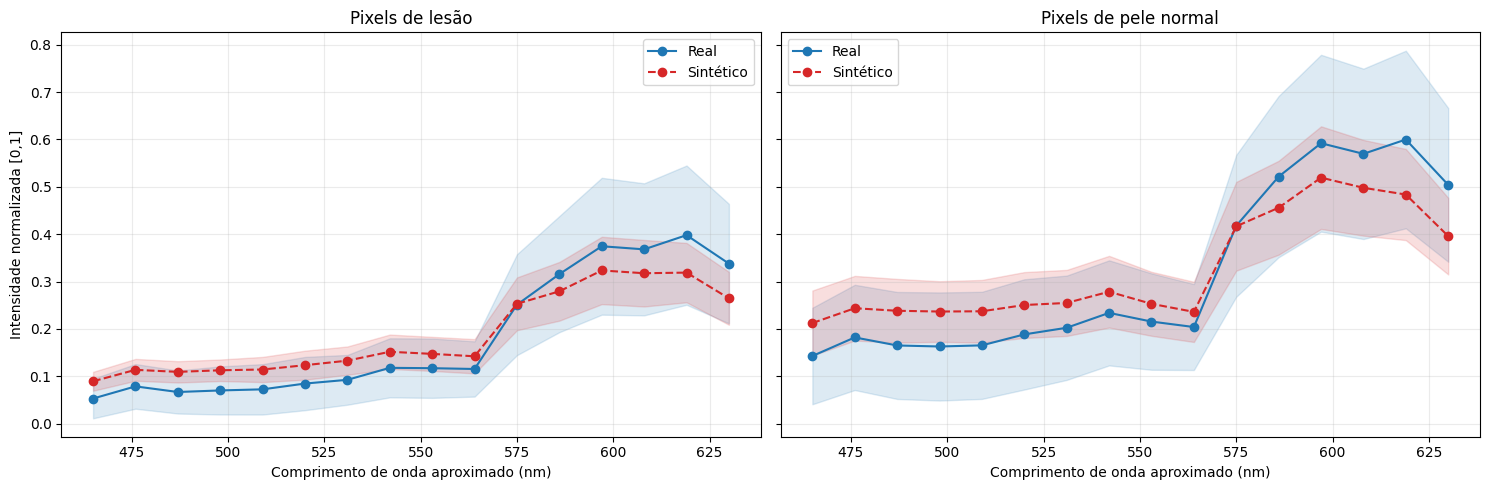

In [14]:
real_lesion_specs, real_normal_specs = [], []
for subset_i, global_i in enumerate(test_indices):
    item = real_test[subset_i]
    cube = ((item['image'].float() + 1.0) / 2.0).clamp(0, 1).permute(1, 2, 0).numpy()
    mask = load_combined_mask(real_base.get_masks_list(int(global_i)), cube.shape[:2])
    if mask is None:
        mask = otsu_lesion_mask(cube)
    lesion, normal = mean_spectra(cube, mask)
    real_lesion_specs.append(lesion)
    real_normal_specs.append(normal)

fake_lesion_specs, fake_normal_specs = [], []
for i in range(len(fake_dataset)):
    cube = fake_dataset[i]['image'].permute(1, 2, 0).numpy()
    lesion, normal = mean_spectra(cube, otsu_lesion_mask(cube))
    fake_lesion_specs.append(lesion)
    fake_normal_specs.append(normal)

def plot_mean_std(ax, spectra, color, label, linestyle='-'):
    arr = np.asarray(spectra)
    mean, std = np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)
    ax.plot(WAVELENGTHS_NM, mean, color=color, linestyle=linestyle, marker='o', label=label)
    ax.fill_between(WAVELENGTHS_NM, mean - std, mean + std, color=color, alpha=0.15)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
plot_mean_std(axes[0], real_lesion_specs, 'C0', 'Real')
plot_mean_std(axes[0], fake_lesion_specs, 'C3', 'Sintético', '--')
axes[0].set_title('Pixels de lesão')

plot_mean_std(axes[1], real_normal_specs, 'C0', 'Real')
plot_mean_std(axes[1], fake_normal_specs, 'C3', 'Sintético', '--')
axes[1].set_title('Pixels de pele normal')

for ax in axes:
    ax.set_xlabel('Comprimento de onda aproximado (nm)')
    ax.grid(alpha=0.25)
    ax.legend()
axes[0].set_ylabel('Intensidade normalizada [0,1]')
plt.tight_layout()
plt.show()

## Embeddings compartilhados: RGB × HSI sintético × HSI real

Para colocar os três domínios no **mesmo espaço de características**, todos precisam passar pelo mesmo extrator e possuir o mesmo número de canais:

- RGB: imagem original em 3 canais;
- HSI real e sintético: média das 16 bandas repetida em 3 canais, seguindo `scripts/make_grid.py`;
- extrator: InceptionV3 pré-treinado, retornando um vetor de 2048 características por imagem;
- projeção: PCA ajustada conjuntamente nos três grupos.

Esses embeddings representam principalmente padrões visuais aprendidos em imagens naturais: forma da lesão, bordas, distribuição espacial, contraste e textura. Eles **não representam toda a assinatura espectral**, porque as 16 bandas foram condensadas em uma imagem de intensidade média. Proximidade no gráfico sugere semelhança visual no espaço do extrator, não equivalência clínica ou espectral.

In [18]:
from sklearn.decomposition import PCA
from torch.nn import functional as F

RGB_IMAGES_DIR = PROJECT_ROOT / 'data/milk10k_melanoma_cropped_256/images'
MAX_RGB_SAMPLES = None  # use um inteiro para limitar, ou None para todas


class RGBImageDataset(Dataset):
    def __init__(self, root: Path, max_samples=None):
        extensions = {'.jpg', '.jpeg', '.png'}
        self.files = sorted(p for p in root.rglob('*') if p.suffix.lower() in extensions)
        if max_samples is not None:
            self.files = self.files[:max_samples]
        if not self.files:
            raise ValueError(f'Nenhuma imagem RGB encontrada em {root}')

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        image = Image.open(self.files[index]).convert('RGB').resize((256, 256))
        array = np.asarray(image, dtype=np.float32) / 255.0
        tensor = torch.from_numpy(array).permute(2, 0, 1).contiguous()
        return {'image': tensor, 'path': str(self.files[index])}


class HSIVisualDataset(Dataset):
    """Converte HSI normalizado para a visualização média em três canais."""
    def __init__(self, dataset, real_m11=False):
        self.dataset = dataset
        self.real_m11 = real_m11

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        item = self.dataset[index]
        hsi = item['image'].float()
        if self.real_m11:
            hsi = ((hsi + 1.0) / 2.0).clamp(0, 1)
        else:
            hsi = hsi.clamp(0, 1)
        visual = hsi.mean(dim=0, keepdim=True).repeat(3, 1, 1)
        return {'image': visual}


rgb_dataset = RGBImageDataset(RGB_IMAGES_DIR, MAX_RGB_SAMPLES)
real_visual_dataset = HSIVisualDataset(real_test, real_m11=True)
fake_visual_dataset = HSIVisualDataset(fake_dataset, real_m11=False)

print('RGB:', len(rgb_dataset))
print('HSI real:', len(real_visual_dataset))
print('HSI sintético:', len(fake_visual_dataset))

RGB: 100
HSI real: 15
HSI sintético: 100


/mnt/datahdd/aline_conda/miniconda3/envs/hyperskin/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/datahdd/aline_conda/miniconda3/envs/hyperskin/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/mnt/datahdd/aline_conda/miniconda3/envs/hyperskin/lib/python3.12/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


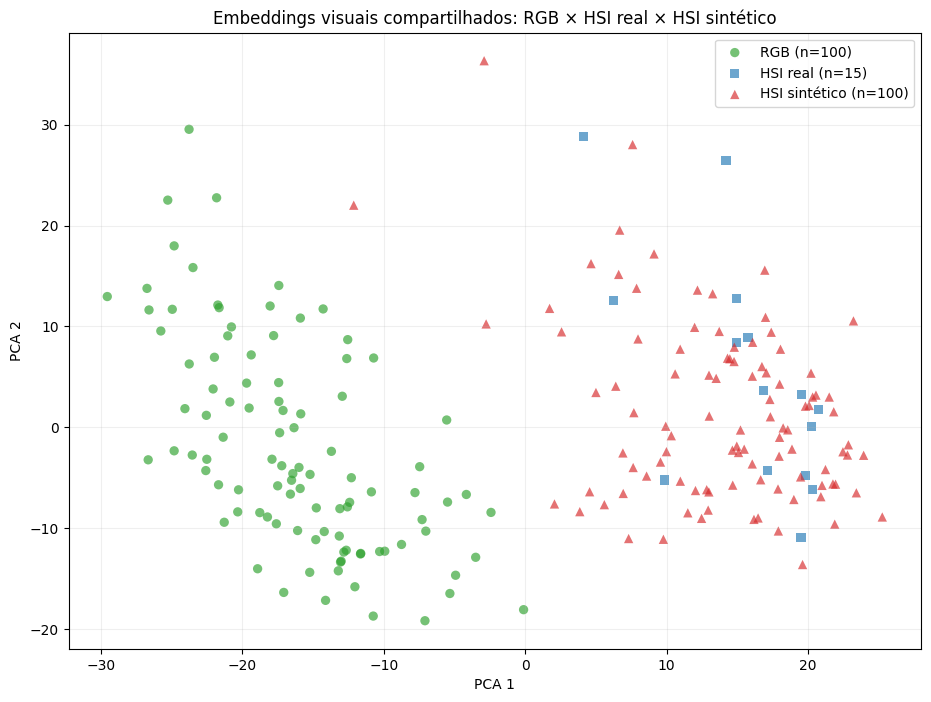

,comparação,distância euclidiana entre centroides
0,RGB × HSI real,35.360031
1,RGB × HSI sintético,30.696423
2,HSI real × HSI sintético,17.088743


In [19]:
# O mesmo extrator processa os três grupos.
shared_encoder = InceptionV3Wrapper(normalize_input=True, in_chans=3).to(DEVICE).eval()


@torch.no_grad()
def extract_shared_embeddings(dataset, batch_size=BATCH_SIZE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    embeddings = []
    for batch in loader:
        images = batch['image'].float().clamp(0, 1).to(DEVICE)
        # InceptionV3Wrapper já redimensiona internamente para 299 × 299.
        embeddings.append(shared_encoder(images).cpu().numpy())
    return np.concatenate(embeddings, axis=0)


rgb_embeddings = extract_shared_embeddings(rgb_dataset)
real_hsi_embeddings = extract_shared_embeddings(real_visual_dataset)
fake_hsi_embeddings = extract_shared_embeddings(fake_visual_dataset)

all_embeddings = np.concatenate(
    [rgb_embeddings, real_hsi_embeddings, fake_hsi_embeddings], axis=0
)
domains = np.array(
    ['RGB'] * len(rgb_embeddings)
    + ['HSI real'] * len(real_hsi_embeddings)
    + ['HSI sintético'] * len(fake_hsi_embeddings)
)

# Padronização por dimensão antes da PCA evita que poucas ativações de grande escala dominem.
embedding_mean = all_embeddings.mean(axis=0, keepdims=True)
embedding_std = all_embeddings.std(axis=0, keepdims=True) + 1e-8
all_embeddings_standardized = (all_embeddings - embedding_mean) / embedding_std

pca_embeddings = PCA(n_components=2, random_state=SEED).fit_transform(
    all_embeddings_standardized
)

colors = {'RGB': 'C2', 'HSI real': 'C0', 'HSI sintético': 'C3'}
markers = {'RGB': 'o', 'HSI real': 's', 'HSI sintético': '^'}

plt.figure(figsize=(11, 8))
for domain in ['RGB', 'HSI real', 'HSI sintético']:
    mask = domains == domain
    plt.scatter(
        pca_embeddings[mask, 0],
        pca_embeddings[mask, 1],
        label=f'{domain} (n={mask.sum()})',
        color=colors[domain],
        marker=markers[domain],
        alpha=0.65,
        s=45,
        edgecolors='none',
    )
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Embeddings visuais compartilhados: RGB × HSI real × HSI sintético')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

# Distâncias entre centroides no espaço padronizado completo, antes da projeção 2D.
centroids = {
    domain: all_embeddings_standardized[domains == domain].mean(axis=0)
    for domain in np.unique(domains)
}
centroid_rows = []
for left, right in [('RGB', 'HSI real'), ('RGB', 'HSI sintético'), ('HSI real', 'HSI sintético')]:
    centroid_rows.append({
        'comparação': f'{left} × {right}',
        'distância euclidiana entre centroides': np.linalg.norm(centroids[left] - centroids[right]),
    })
pd.DataFrame(centroid_rows)

## Conclusões de interpretação

- Use o **FID** para comparar globalmente diferentes geradores ou checkpoints, sempre mantendo o mesmo conjunto real, quantidade de amostras e extrator.
- Use as curvas espectrais de lesão/pele para verificar se a forma e magnitude das assinaturas sintéticas são plausíveis.
- SAM e SSIM só têm interpretação forte quando existe correspondência real–sintética da mesma cena. Neste experimento CycleGAN não pareado, os valores reportados são auxiliares e dependem do alinhamento aleatório por índice.
- Para uma avaliação pareada rigorosa, salve durante a inferência o identificador da imagem RGB e use um dataset que possua o HSI real correspondente àquele RGB.